# Universal Multi-Modal Deep Learning Model for Digital Twin
## Integrating CWRU, NASA, CIA-1, and Current Signature Datasets

---

### 📋 **Project Overview**

This notebook trains a **unified deep learning model** that combines data from **4 different bearing/motor datasets**:

| Dataset | Data Type | Purpose |
|---------|-----------|----------|
| **CWRU** | Vibration (time-series) | Bearing fault classification |
| **NASA IMS** | Vibration (time-series) | RUL estimation (degradation) |
| **CIA-1** | Tabular (sensor readings) | Multi-fault classification |
| **Current Signature** | 3-Phase Current (time-series) | Rotor/bearing fault detection |

---

### 🎯 **Model Objectives (Multi-Task Learning)**

The model simultaneously learns **3 tasks**:

1. **Fault Classification** (6 classes):
   - Healthy
   - Bearing Fault
   - Rotor Fault
   - Tool Wear
   - Overstrain
   - Power Failure

2. **RUL Estimation**: Predict remaining useful life (0.0 = failed, 1.0 = new)

3. **Anomaly Detection**: Binary classification (0 = normal, 1 = anomaly)

---

### 🏗️ **Architecture: Multi-Modal Fusion Network**

```
┌─────────────┐  ┌─────────────┐  ┌─────────────┐
│  Vibration  │  │   Current   │  │   Tabular   │
│   Encoder   │  │   Encoder   │  │   Encoder   │
│ (1D CNN +   │  │ (1D CNN +   │  │    (MLP)    │
│  Attention) │  │  Attention) │  │             │
└──────┬──────┘  └──────┬──────┘  └──────┬──────┘
       │                │                │
       └────────────────┼────────────────┘
                        ▼
              ┌──────────────────┐
              │  Fusion Layer    │
              │ (Cross-Modal     │
              │  Attention)      │
              └────────┬─────────┘
                       │
       ┌───────────────┼───────────────┐
       ▼               ▼               ▼
┌─────────────┐ ┌─────────────┐ ┌─────────────┐
│ Classifier  │ │ RUL Head    │ │ Anomaly Head│
│ (Softmax)   │ │ (Regression)│ │ (Sigmoid)   │
└─────────────┘ └─────────────┘ └─────────────┘
```

**Key Innovation**: The model learns to combine information from different sensor types (vibration, current, temperature, etc.) even when some sensors are missing!

---
## 🔧 Setup & Imports

In [87]:
# System imports
import sys
import os
sys.path.append(os.path.abspath('..'))  # Add project root to path

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Deep Learning
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Custom modules
from src.data.universal_loader import UniversalDataLoader
from src.models.universal_model import UniversalModelBuilder

# Configure plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display TensorFlow configuration
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.20.0
GPU Available: []


---
## 📊 1. Data Loading & Exploration

### What happens here:
1. **Load all 4 datasets** using the `UniversalDataLoader`
2. **Unify the format**: All data is converted to 3 modalities (Vibration, Current, Tabular)
3. **Handle missing data**: If a dataset doesn't have a modality (e.g., CWRU has no tabular data), it's filled with zeros and masked
4. **Split data**: 70% train, 15% validation, 15% test

In [88]:
# Initialize the Universal Data Loader
BASE_DIR = r"d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes"
loader = UniversalDataLoader(BASE_DIR)

# Load and prepare data (this will take 1-2 minutes)
# The loader:
#   1. Loads CWRU vibration data
#   2. Loads Current Signature 3-phase current data
#   3. Loads CIA-1 tabular sensor data
#   4. Loads NASA vibration + RUL data
#   5. Unifies all into a common format
#   6. Creates train/val/test splits
data = loader.prepare_data(split_ratio=(0.7, 0.15, 0.15))

# Extract splits
train_data = data['train']
val_data = data['val']
test_data = data['test']

# Display summary
print("\n=== Dataset Summary ===")
print(f"Training samples: {len(train_data['labels'])}")
print(f"Validation samples: {len(val_data['labels'])}")
print(f"Test samples: {len(test_data['labels'])}")
print(f"\nTotal samples: {len(train_data['labels']) + len(val_data['labels']) + len(test_data['labels'])}")

Loading CWRU Dataset...


Loading Current Signature Dataset...
Found 8 folders for Raw Data Loading...
Processing folder: 3-Phase-current-0.7mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-0.9mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.1mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.3mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.5mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.7mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-12-4mm-broken-rotor-bar-fault -> Label: broken_rotor_bar
Processing folder: 3-Phase-current-healthy-motor -> Label: healthy
Raw Data Loaded: X shape=(2516, 2048, 3), y shape=(2516,)
Loading CIA-1 Dataset...
Loaded CIA-1 Dataset: 500 samples, 9 features
Class distribution: {0: 467, 1: 19, 2: 8, 3: 6}
Loading NASA Dataset (2nd Test)...
DEBUG: X_vib dtype: float64
DEBUG: X_curr dtype: float64
DEBUG: X_tab dtype: o

### 📐 Data Shapes Explained

Each sample has **3 input modalities**:

- **Vibration**: `(samples, 2048, 1)` → 2048 time steps, 1 channel
- **Current**: `(samples, 2048, 3)` → 2048 time steps, 3 phases (A, B, C)
- **Tabular**: `(samples, 9)` → 9 sensor features (temperature, speed, torque, etc.)

And **3 output targets**:

- **Labels**: `(samples, 6)` → One-hot encoded fault classes
- **RUL**: `(samples,)` → Remaining useful life (0.0 to 1.0)
- **Anomaly**: `(samples,)` → Binary (0 or 1)

**Masks** indicate which modalities have real data vs. zeros.

In [89]:
# Display data shapes
print("\n=== Data Shapes ===")
print(f"Vibration: {train_data['vibration'].shape}  ← (samples, time_steps, channels)")
print(f"Current:   {train_data['current'].shape}  ← (samples, time_steps, 3_phases)")
print(f"Tabular:   {train_data['tabular'].shape}  ← (samples, features)")
print(f"Labels:    {train_data['labels'].shape}  ← (samples, num_classes)")
print(f"RUL:       {train_data['rul'].shape}  ← (samples,)")
print(f"Anomaly:   {train_data['anomaly'].shape}  ← (samples,)")
print(f"Masks:     {train_data['masks'].shape}  ← (samples, 3_modalities)")


=== Data Shapes ===
Vibration: (15047, 2048, 1)  ← (samples, time_steps, channels)
Current:   (15047, 2048, 3)  ← (samples, time_steps, 3_phases)
Tabular:   (15047, 9)  ← (samples, features)
Labels:    (15047, 6)  ← (samples, num_classes)
RUL:       (15047,)  ← (samples,)
Anomaly:   (15047,)  ← (samples,)
Masks:     (15047, 3)  ← (samples, 3_modalities)


### 📊 Visualize Data Distribution

This plot shows:
1. **Class Distribution**: How many samples per fault type
2. **Modality Availability**: Which datasets contribute which sensor types
3. **RUL Availability**: Only NASA dataset has RUL labels

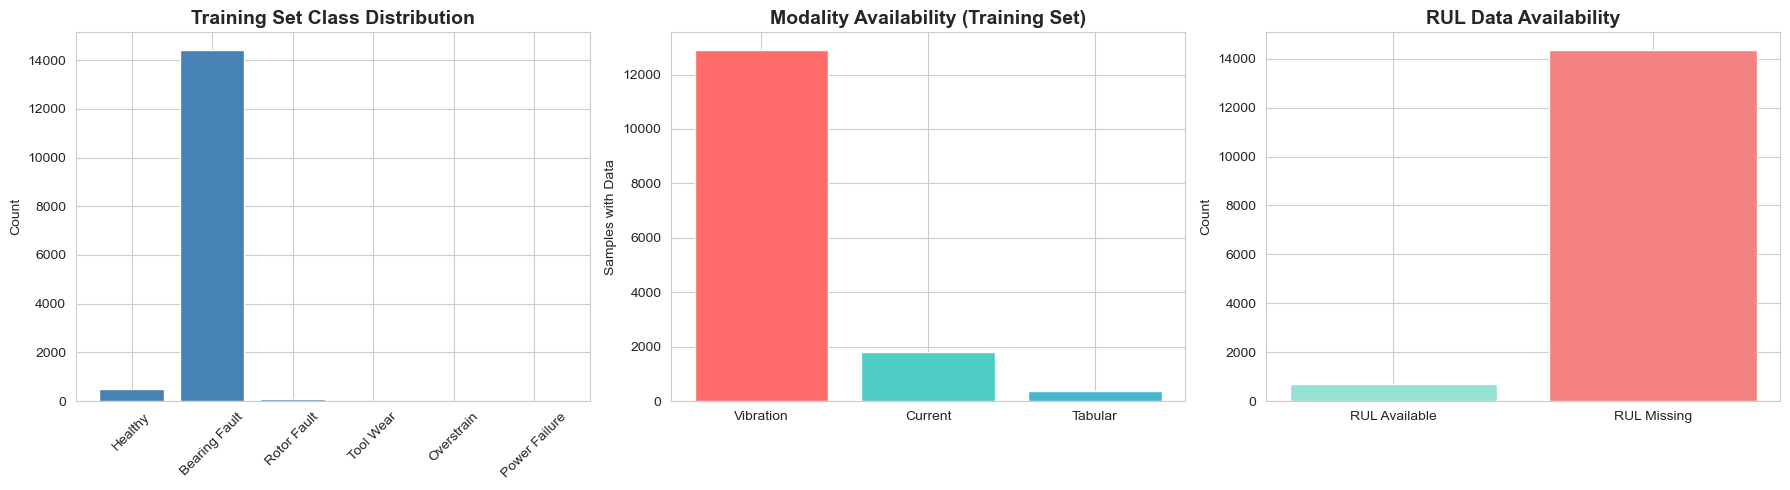

In [90]:
# Define class names
class_names = ['Healthy', 'Bearing Fault', 'Rotor Fault', 'Tool Wear', 'Overstrain', 'Power Failure']

# Convert one-hot labels to class indices
train_labels_idx = np.argmax(train_data['labels'], axis=1)

# Create 3-panel visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Class Distribution
unique, counts = np.unique(train_labels_idx, return_counts=True)
axes[0].bar([class_names[i] for i in unique], counts, color='steelblue')
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Panel 2: Modality Availability
# Masks tell us which samples have real data (1) vs. zeros (0)
modality_names = ['Vibration', 'Current', 'Tabular']
modality_counts = np.sum(train_data['masks'], axis=0)
axes[1].bar(modality_names, modality_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('Modality Availability (Training Set)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Samples with Data')

# Panel 3: RUL Availability
rul_available = np.sum(train_data['mask_rul'])
rul_missing = len(train_data['mask_rul']) - rul_available
axes[2].bar(['RUL Available', 'RUL Missing'], [rul_available, rul_missing], color=['#95E1D3', '#F38181'])
axes[2].set_title('RUL Data Availability', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Trained_models', 'universal_model', 'data_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## 🏗️ 2. Model Architecture

### How the model works:

1. **Encoders** (3 separate neural networks):
   - **Vibration Encoder**: 1D CNN + Self-Attention → Extracts features from vibration signals
   - **Current Encoder**: 1D CNN + Self-Attention → Extracts features from 3-phase current
   - **Tabular Encoder**: MLP (Dense layers) → Processes sensor readings

2. **Fusion Layer**:
   - Uses **Cross-Modal Attention** to let different modalities "talk" to each other
   - Example: Vibration features can influence how current features are interpreted

3. **Task Heads** (3 separate outputs):
   - **Classification Head**: Softmax → Fault type probabilities
   - **RUL Head**: Linear → Continuous RUL value
   - **Anomaly Head**: Sigmoid → Anomaly probability

**Total Parameters**: ~1.7 million (relatively small for a multi-modal model!)

In [91]:
# Build the Universal Model
builder = UniversalModelBuilder(num_classes=loader.num_classes)
model = builder.build_model()

# Display the architecture
# This shows all layers, their output shapes, and parameter counts
model.summary()

Model: "universal_digital_twin_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vibration           │ (None, 2048, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ current             │ (None, 2048, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vibration_encoder   │ (None, 256)       │    405,120 │ vibration[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ current_encoder     │ (None, 256)       │    406,016 │ current[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_encoder     │ (None, 256)       │    102,656 │ tabular[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_27          │ (None, 1, 256)    │          0 │ vibration_encode… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_28          │ (None, 1, 256)    │          0 │ current_encoder[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_29          │ (None, 1, 256)    │          0 │ tabular_encoder[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 3, 256)    │          0 │ reshape_27[0][0], │
│ (Concatenate)       │                   │            │ reshape_28[0][0], │
│                     │                   │            │ reshape_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 3, 256)    │    263,168 │ concatenate_9[0]… │
│ (MultiHeadAttentio… │                   │            │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_86          │ (None, 512)       │          0 │ dense_75[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 256)       │    131,328 │ dropout_86[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 256)       │    131,328 │ dropout_86[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_88          │ (None, 256)       │          0 │ dense_77[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,720,840 (6.56 MB)

 Trainable params: 1,717,768 (6.55 MB)

 Non-trainable params: 3,072 (12.00 KB)

### 🎯 Model Compilation

**Multi-Task Loss Function**:

```
Total Loss = 1.0 × Classification Loss + 0.5 × RUL Loss + 0.3 × Anomaly Loss
```

**Why different weights?**
- Classification is the **primary task** (weight = 1.0)
- RUL is **important but secondary** (weight = 0.5)
- Anomaly detection is **auxiliary** (weight = 0.3)

This tells the model to prioritize getting fault classification right, while still learning RUL and anomaly detection.

In [92]:
# Define loss functions for each task
losses = {
    'classification_head': 'categorical_crossentropy',  # For multi-class classification
    'rul_head': 'mse',  # Mean Squared Error for regression
    'anomaly_head': 'binary_crossentropy'  # For binary classification
}

# Define loss weights (importance of each task)
loss_weights = {
    'classification_head': 1.0,  # Primary task
    'rul_head': 0.5,  # Secondary task
    'anomaly_head': 0.3  # Auxiliary task
}

# Define metrics to track during training
metrics = {
    'classification_head': 'accuracy',  # % of correct predictions
    'rul_head': 'mae',  # Mean Absolute Error
    'anomaly_head': 'AUC'  # Area Under ROC Curve
}

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Adam optimizer with lr=0.001
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


---
## 🚀 3. Training

### Training Strategy:

1. **Callbacks** (automatic training control):
   - **EarlyStopping**: Stop if validation loss doesn't improve for 10 epochs
   - **ReduceLROnPlateau**: Cut learning rate in half if stuck for 5 epochs
   - **ModelCheckpoint**: Save the best model automatically

2. **Training Parameters**:
   - **Epochs**: 30 (but will likely stop early due to EarlyStopping)
   - **Batch Size**: 32 samples per update
   - **Validation**: Check performance on validation set after each epoch

**Expected Training Time**: ~2-4 hours (depending on your CPU/GPU)

In [93]:
# Create directory for saving models
MODEL_SAVE_DIR = os.path.join(BASE_DIR, 'Trained_models', 'universal_model')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Define callbacks
callbacks = [
    # Stop training if validation loss doesn't improve for 10 epochs
    EarlyStopping(
        monitor='val_classification_head_loss',
        mode='min',
        patience=10,
        restore_best_weights=True,
        mode='min',
        verbose=1
    ),
    
    # Reduce learning rate if stuck (helps escape local minima)
    ReduceLROnPlateau(
        monitor='val_classification_head_loss',
        mode='min',
        factor=0.5,  # Multiply LR by 0.5
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Save the best model (lowest validation loss)
    ModelCheckpoint(
        os.path.join(MODEL_SAVE_DIR, 'best_universal_model.keras'),
        save_best_only=True,
        verbose=1
    )
]

In [94]:
# Compute Sample Weights (Robust for multi-output models)
from sklearn.utils.class_weight import compute_sample_weight

# Convert one-hot to indices
y_train_indices = np.argmax(train_data['labels'], axis=1)

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_indices)

print(f"Sample Weights Shape: {sample_weights.shape}")
print(f"Sample Weights Example (First 10): {sample_weights[:10]}")

# Train the model with sample weights
history = model.fit(
    x={
        'vibration': train_data['vibration'],
        'current': train_data['current'],
        'tabular': train_data['tabular']
    },
    y=[
        train_data['labels'],      # Output 0: classification_head
        train_data['rul'],          # Output 1: rul_head
        train_data['anomaly']       # Output 2: anomaly_head
    ],
    validation_data=(
        {
            'vibration': val_data['vibration'],
            'current': val_data['current'],
            'tabular': val_data['tabular']
        },
        [
            val_data['labels'],     # Output 0: classification_head
            val_data['rul'],        # Output 1: rul_head
            val_data['anomaly']     # Output 2: anomaly_head
        ]
    ),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    sample_weight=[
        sample_weights,                    # For classification_head (balanced)
        np.ones_like(sample_weights),      # For rul_head (equal weight)
        np.ones_like(sample_weights)       # For anomaly_head (equal weight)
    ]
)

Sample Weights Shape: (15047,)
Sample Weights Example (First 10): [0.17390149 0.17390149 0.17390149 0.17390149 0.17390149 0.17390149
 0.17390149 0.17390149 0.17390149 0.17390149]
Epoch 1/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - anomaly_head_AUC: 0.8484 - anomaly_head_loss: 0.1411 - classification_head_accuracy: 0.8150 - classification_head_loss: 3.5300 - loss: 3.5863 - rul_head_loss: 0.0280 - rul_head_mae: 0.0872
Epoch 1: val_loss improved from None to 1.87575, saving model to d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\universal_model\best_universal_model.keras
471/471 ━━━━━━━━━━━━━━━━━━━━ 845s 2s/step - anomaly_head_AUC: 0.8261 - anomaly_head_loss: 0.1406 - classification_head_accuracy: 0.6014 - classification_head_loss: 3.4404 - loss: 3.4978 - rul_head_loss: 0.0199 - rul_head_mae: 0.0666 - val_anomaly_head_AUC: 0.5000 - val_anomaly_head_loss: 0.1429 - val_classification_head_accuracy: 0.0322 - val_classification_head_loss: 1.8255 - val_loss: 1.

---
## 📈 4. Training Visualizations

### What to look for in these plots:

**Good Signs**:
- ✅ Training and validation curves **decrease together**
- ✅ Validation curve is **close to** training curve
- ✅ Curves **flatten out** (convergence)

**Bad Signs**:
- ❌ Validation curve **increases** while training decreases (overfitting)
- ❌ Large **gap** between training and validation (overfitting)
- ❌ Curves are **noisy/unstable** (learning rate too high)

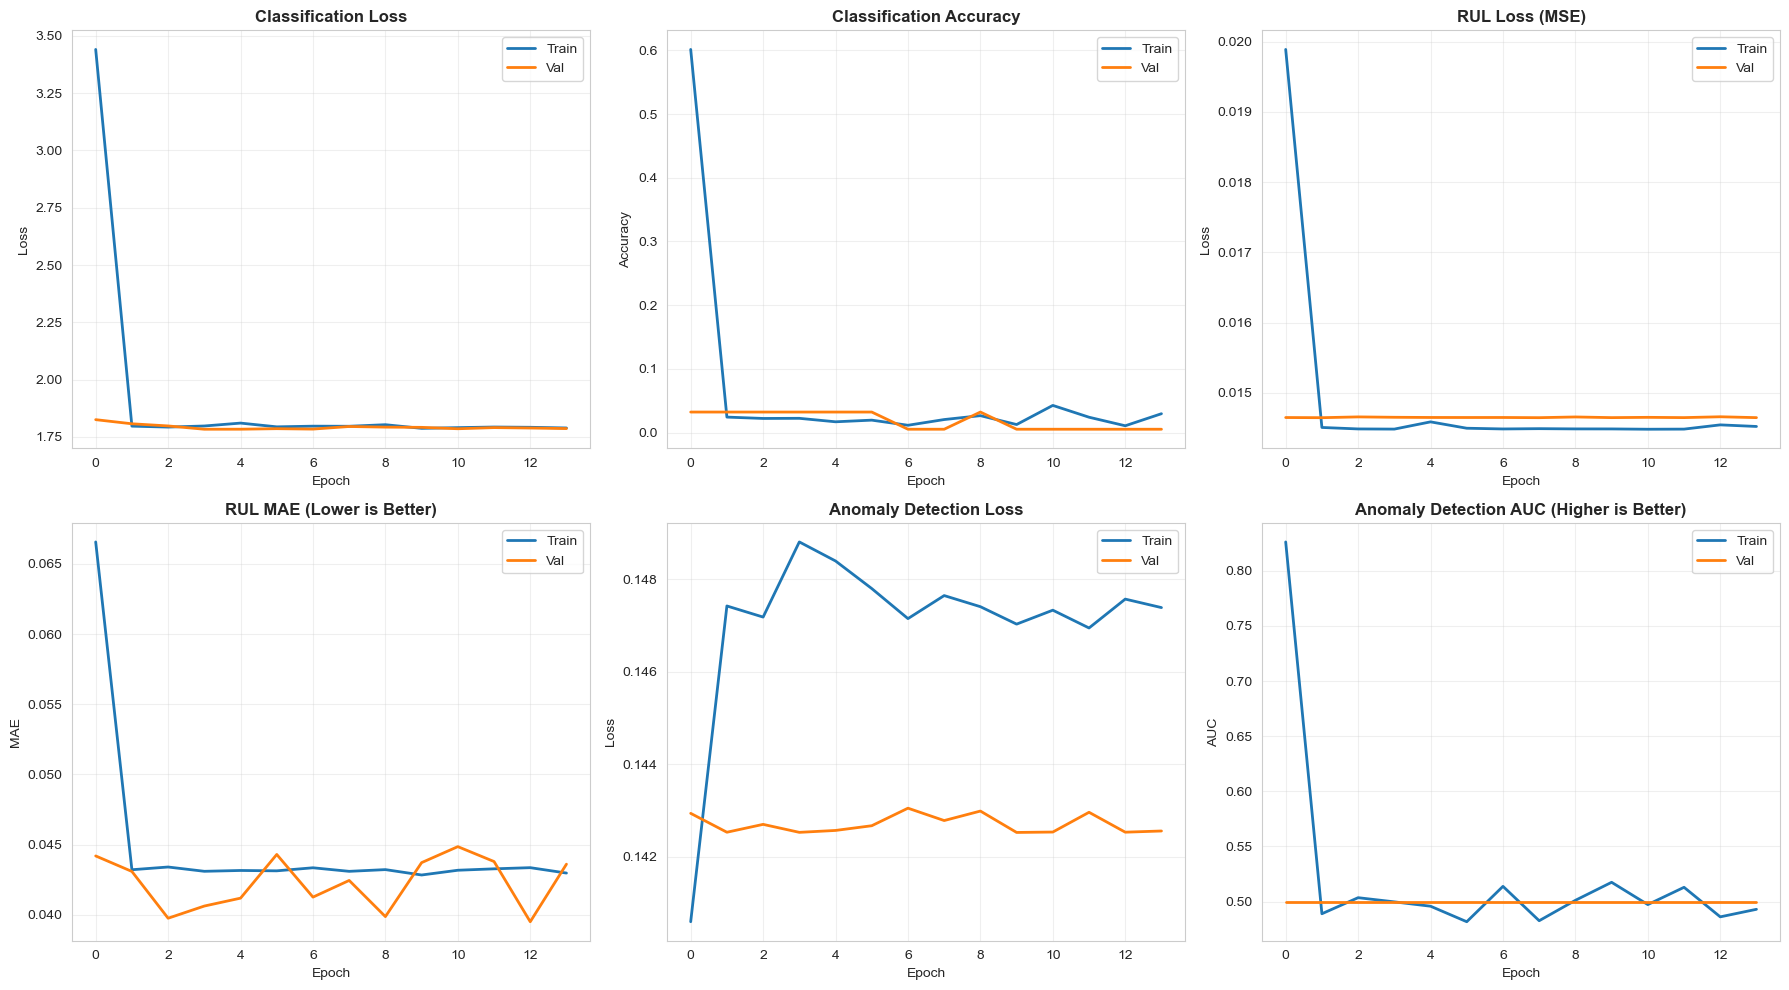

In [95]:
# Plot training history (6 subplots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1, Column 1: Classification Loss
axes[0, 0].plot(history.history['classification_head_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_classification_head_loss'], label='Val', linewidth=2)
axes[0, 0].set_title('Classification Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Row 1, Column 2: Classification Accuracy
axes[0, 1].plot(history.history['classification_head_accuracy'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_classification_head_accuracy'], label='Val', linewidth=2)
axes[0, 1].set_title('Classification Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 1, Column 3: RUL Loss (MSE)
axes[0, 2].plot(history.history['rul_head_loss'], label='Train', linewidth=2)
axes[0, 2].plot(history.history['val_rul_head_loss'], label='Val', linewidth=2)
axes[0, 2].set_title('RUL Loss (MSE)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Row 2, Column 1: RUL MAE
axes[1, 0].plot(history.history['rul_head_mae'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_rul_head_mae'], label='Val', linewidth=2)
axes[1, 0].set_title('RUL MAE (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Row 2, Column 2: Anomaly Loss
axes[1, 1].plot(history.history['anomaly_head_loss'], label='Train', linewidth=2)
axes[1, 1].plot(history.history['val_anomaly_head_loss'], label='Val', linewidth=2)
axes[1, 1].set_title('Anomaly Detection Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Row 2, Column 3: Anomaly AUC
axes[1, 2].plot(history.history['anomaly_head_AUC'], label='Train', linewidth=2)
axes[1, 2].plot(history.history['val_anomaly_head_AUC'], label='Val', linewidth=2)
axes[1, 2].set_title('Anomaly Detection AUC (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUC')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## 🧪 5. Evaluation on Test Set

Now we test the model on **completely unseen data** (15% of total samples).

This is the **true measure** of model performance!

In [96]:
# Generate predictions on test set
predictions = model.predict({
    'vibration': test_data['vibration'],
    'current': test_data['current'],
    'tabular': test_data['tabular']
})

# Extract predictions for each task
pred_class = predictions[0]  # Shape: (n_samples, 6) - probabilities for each class
pred_rul = predictions[1]  # Shape: (n_samples, 1) - RUL values
pred_anomaly = predictions[2]  # Shape: (n_samples, 1) - anomaly probabilities

# Convert one-hot labels to class indices
true_class_idx = np.argmax(test_data['labels'], axis=1)  # True class (0-5)
pred_class_idx = np.argmax(pred_class, axis=1)  # Predicted class (0-5)

print("\n=== Test Set Predictions Complete ===")

101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 301ms/step

=== Test Set Predictions Complete ===


### 📊 Classification Report

This shows **per-class performance**:
- **Precision**: Of all samples predicted as class X, how many were actually class X?
- **Recall**: Of all actual class X samples, how many did we correctly identify?
- **F1-Score**: Harmonic mean of precision and recall (balanced metric)

In [97]:
# Print detailed classification report
print("\n=== Classification Report ===")
print(classification_report(true_class_idx, pred_class_idx, target_names=class_names, labels=range(len(class_names)), zero_division=0))


=== Classification Report ===
               precision    recall  f1-score   support

      Healthy       0.04      1.00      0.07       116
Bearing Fault       0.00      0.00      0.00      3087
  Rotor Fault       0.00      0.00      0.00        18
    Tool Wear       0.00      0.00      0.00         2
   Overstrain       0.00      0.00      0.00         1
Power Failure       0.00      0.00      0.00         1

     accuracy                           0.04      3225
    macro avg       0.01      0.17      0.01      3225
 weighted avg       0.00      0.04      0.00      3225



### 🔥 Confusion Matrix

**How to read this**:
- **Diagonal** (top-left to bottom-right): Correct predictions
- **Off-diagonal**: Misclassifications

Example: If row "Bearing Fault" has a value in column "Healthy", it means some bearing faults were incorrectly classified as healthy.

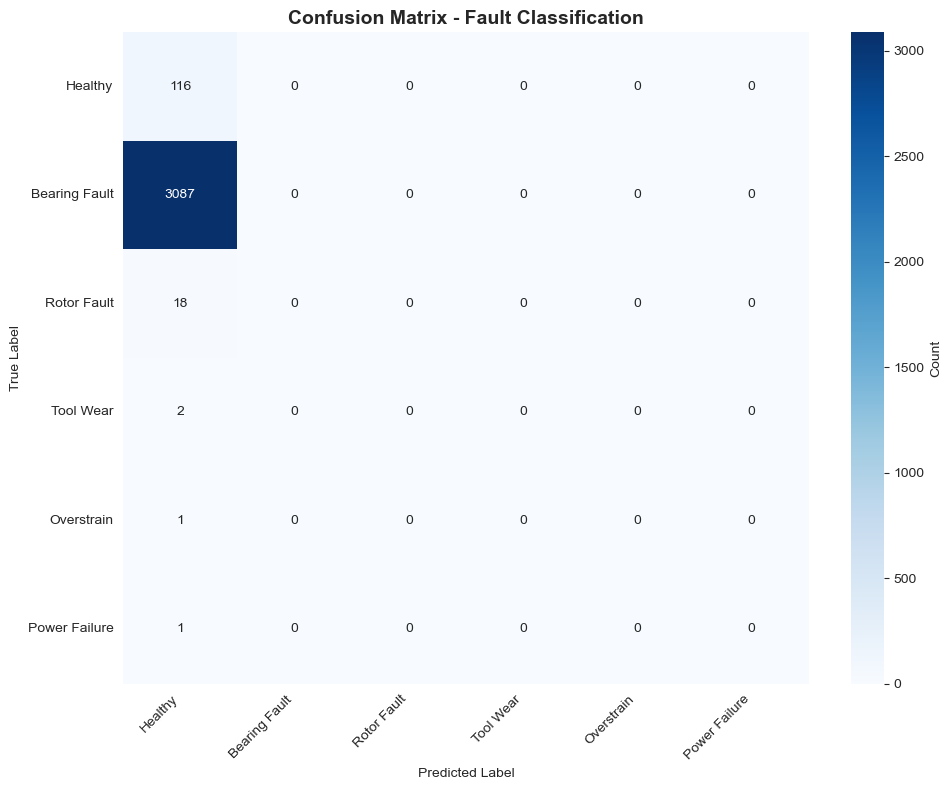

In [98]:
# Compute confusion matrix
cm = confusion_matrix(true_class_idx, pred_class_idx)

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, 
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Fault Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

### 📉 ROC Curves (Receiver Operating Characteristic)

**What is ROC?**
- Shows the trade-off between **True Positive Rate** (sensitivity) and **False Positive Rate**
- **AUC** (Area Under Curve): Overall performance metric
  - AUC = 1.0: Perfect classifier
  - AUC = 0.5: Random guessing
  - AUC > 0.8: Good performance

We plot **one curve per class** (One-vs-Rest strategy).

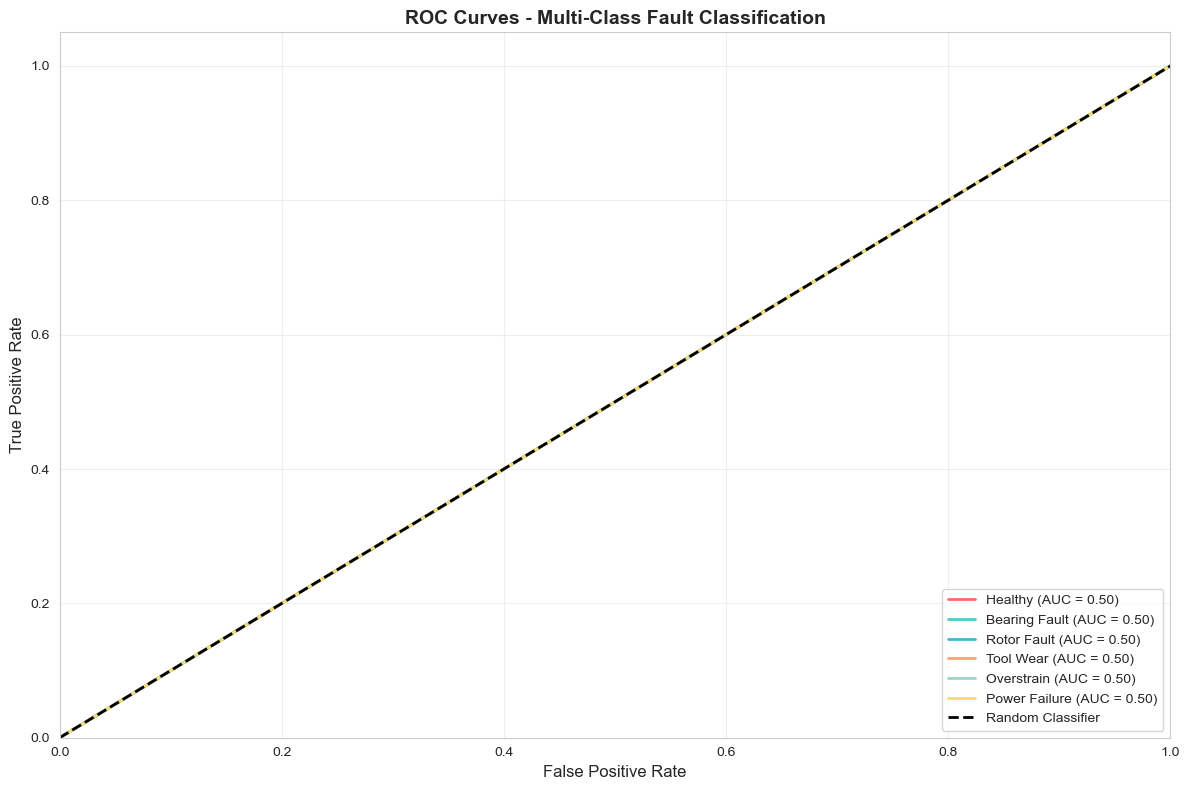

In [99]:
# Compute ROC curves for each class
n_classes = loader.num_classes
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under Curve

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_data['labels'][:, i], pred_class[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, 
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Add diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Multi-Class Fault Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

### ⏳ RUL Estimation Performance

**Note**: Only NASA dataset has RUL labels, so we filter to only those samples.

**Metrics**:
- **MAE** (Mean Absolute Error): Average difference between true and predicted RUL
- **RMSE** (Root Mean Squared Error): Penalizes large errors more heavily

**Ideal**: Points should lie on the red diagonal line (perfect prediction).


=== RUL Estimation Performance ===
MAE: 0.4926
RMSE: 0.5689


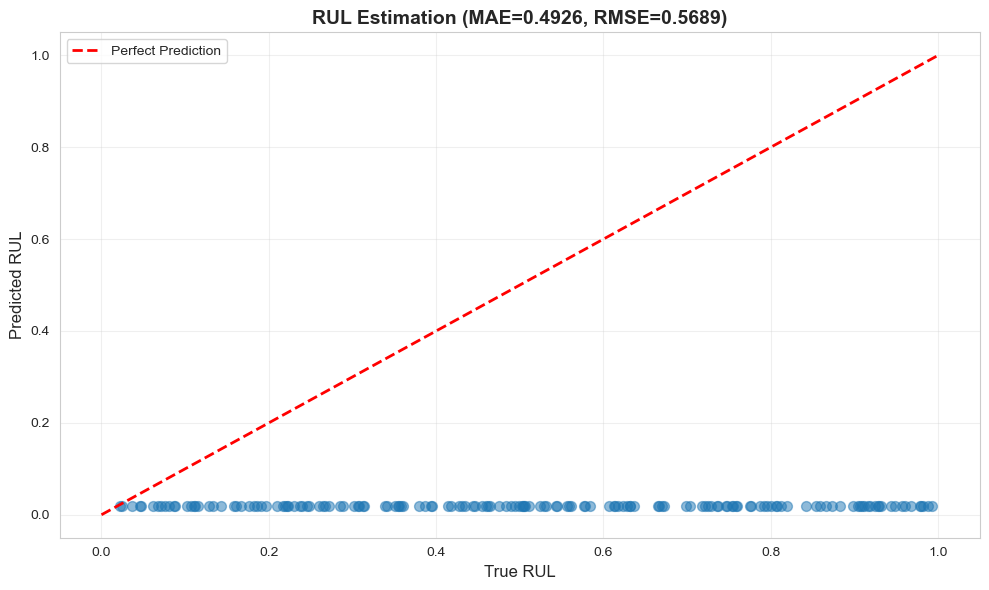

In [100]:
# Filter to samples with RUL data (NASA dataset only)
rul_mask = test_data['mask_rul'] > 0

if np.sum(rul_mask) > 0:
    # Extract true and predicted RUL for NASA samples
    true_rul = test_data['rul'][rul_mask]
    pred_rul_filtered = pred_rul[rul_mask].flatten()
    
    # Calculate metrics
    mae = np.mean(np.abs(true_rul - pred_rul_filtered))
    rmse = np.sqrt(np.mean((true_rul - pred_rul_filtered)**2))
    
    print(f"\n=== RUL Estimation Performance ===")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    # Scatter plot: True vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(true_rul, pred_rul_filtered, alpha=0.5, s=50)
    plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
    plt.xlabel('True RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.title(f'RUL Estimation (MAE={mae:.4f}, RMSE={rmse:.4f})', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'rul_scatter.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No RUL data available in test set.")

### 🚨 Anomaly Detection Performance

**Binary Classification**: Normal (0) vs. Anomaly (1)

**AUC Interpretation**:
- AUC > 0.9: Excellent
- AUC > 0.8: Good
- AUC > 0.7: Fair
- AUC < 0.7: Poor


=== Anomaly Detection Performance ===
AUC: 0.5000


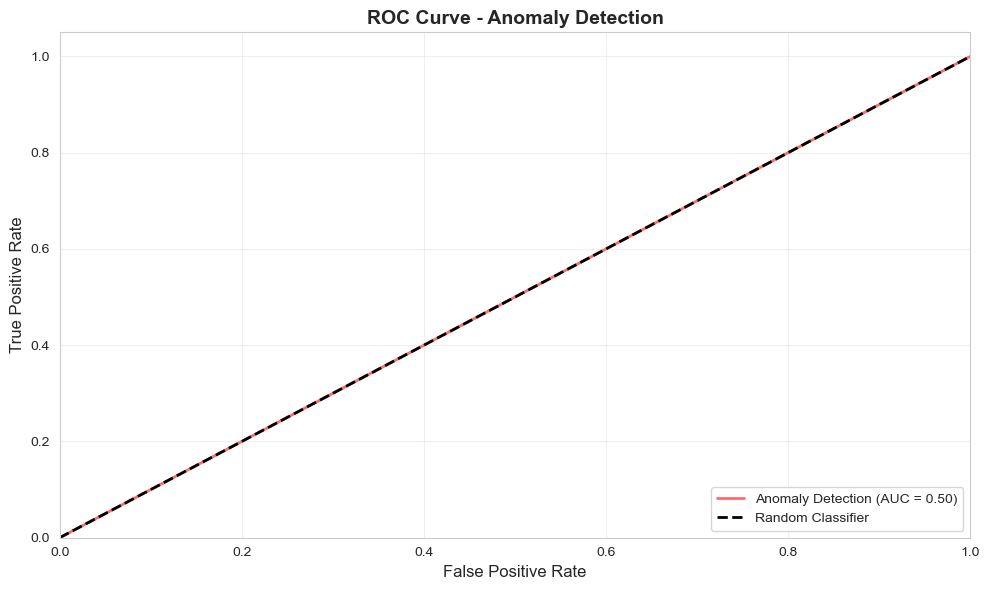

In [101]:
# Calculate anomaly detection AUC
from sklearn.metrics import roc_auc_score

anomaly_auc = roc_auc_score(test_data['anomaly'], pred_anomaly)
print(f"\n=== Anomaly Detection Performance ===")
print(f"AUC: {anomaly_auc:.4f}")

# Plot ROC curve
fpr_anom, tpr_anom, _ = roc_curve(test_data['anomaly'], pred_anomaly)

plt.figure(figsize=(10, 6))
plt.plot(fpr_anom, tpr_anom, color='#FF6B6B', lw=2, 
         label=f'Anomaly Detection (AUC = {anomaly_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Anomaly Detection', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'anomaly_roc.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## 📋 6. Final Summary

This cell prints a **comprehensive performance report** for all 3 tasks.

In [102]:
# Calculate final metrics
from sklearn.metrics import accuracy_score, f1_score

test_acc = accuracy_score(true_class_idx, pred_class_idx)
test_f1 = f1_score(true_class_idx, pred_class_idx, average='weighted')

# Print formatted summary
print("\n" + "="*60)
print("UNIVERSAL MODEL - FINAL PERFORMANCE SUMMARY")
print("="*60)
print(f"\n1. FAULT CLASSIFICATION:")
print(f"   - Test Accuracy: {test_acc*100:.2f}%")
print(f"   - Weighted F1-Score: {test_f1:.4f}")
print(f"\n2. RUL ESTIMATION:")
if np.sum(rul_mask) > 0:
    print(f"   - MAE: {mae:.4f}")
    print(f"   - RMSE: {rmse:.4f}")
else:
    print(f"   - No RUL data in test set")
print(f"\n3. ANOMALY DETECTION:")
print(f"   - AUC: {anomaly_auc:.4f}")
print(f"\n4. MODEL PARAMETERS:")
print(f"   - Total Parameters: {model.count_params():,}")
print(f"   - Trainable Parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("\n" + "="*60)
print(f"Model saved to: {MODEL_SAVE_DIR}")
print("="*60)


UNIVERSAL MODEL - FINAL PERFORMANCE SUMMARY

1. FAULT CLASSIFICATION:
   - Test Accuracy: 3.60%
   - Weighted F1-Score: 0.0025

2. RUL ESTIMATION:
   - MAE: 0.4926
   - RMSE: 0.5689

3. ANOMALY DETECTION:
   - AUC: 0.5000

4. MODEL PARAMETERS:
   - Total Parameters: 1,720,840
   - Trainable Parameters: 1,717,768

Model saved to: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\universal_model


---
## 💾 7. Save Model & Results

This cell saves:
1. **Final trained model** (`.keras` file)
2. **Training history** (`.pkl` file) - for later analysis
3. **Results summary** (`.json` file) - for easy reading

In [103]:
# Save final model
model.save(os.path.join(MODEL_SAVE_DIR, 'final_universal_model.keras'))
print(f"✅ Final model saved to: {os.path.join(MODEL_SAVE_DIR, 'final_universal_model.keras')}")

# Save training history (for later plotting)
import pickle
with open(os.path.join(MODEL_SAVE_DIR, 'training_history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)
print(f"✅ Training history saved.")

# Save results summary as JSON
results = {
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'anomaly_auc': float(anomaly_auc),
    'total_params': int(model.count_params())
}

if np.sum(rul_mask) > 0:
    results['rul_mae'] = float(mae)
    results['rul_rmse'] = float(rmse)

import json
with open(os.path.join(MODEL_SAVE_DIR, 'results_summary.json'), 'w') as f:
    json.dump(results, f, indent=4)
print(f"✅ Results summary saved.")

print("\n🎉 All outputs saved successfully!")
print(f"\n📁 Check the folder: {MODEL_SAVE_DIR}")
print("   You'll find:")
print("   - best_universal_model.keras (best checkpoint)")
print("   - final_universal_model.keras (final model)")
print("   - training_history.pkl (loss curves)")
print("   - results_summary.json (metrics)")
print("   - *.png (all plots)")

✅ Final model saved to: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\universal_model\final_universal_model.keras
✅ Training history saved.
✅ Results summary saved.

🎉 All outputs saved successfully!

📁 Check the folder: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\universal_model
   You'll find:
   - best_universal_model.keras (best checkpoint)
   - final_universal_model.keras (final model)
   - training_history.pkl (loss curves)
   - results_summary.json (metrics)
   - *.png (all plots)
